In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define base path
BASE_DIR = "/content/drive/MyDrive/ANNAM.AI Hackathon/soil_classification-2025"
train_img_dir = BASE_DIR + "/train"
test_img_dir = BASE_DIR + "/test"

train_csv_path = BASE_DIR + "/train_labels.csv"
test_csv_path = BASE_DIR + "/test_ids.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Loaded training labels. Shape: (1222, 2)


,image_id,soil_type
0,img_ed005410.jpg,Alluvial soil
1,img_0c5ecd2a.jpg,Alluvial soil
2,img_ed713bb5.jpg,Alluvial soil
3,img_12c58874.jpg,Alluvial soil
4,img_eff357af.jpg,Alluvial soil



🔍 Checking for missing values and duplicates in training data...
Missing values per column:
 image_id     0
soil_type    0
dtype: int64
Number of duplicate rows: 0
🚨 Missing training images: 0


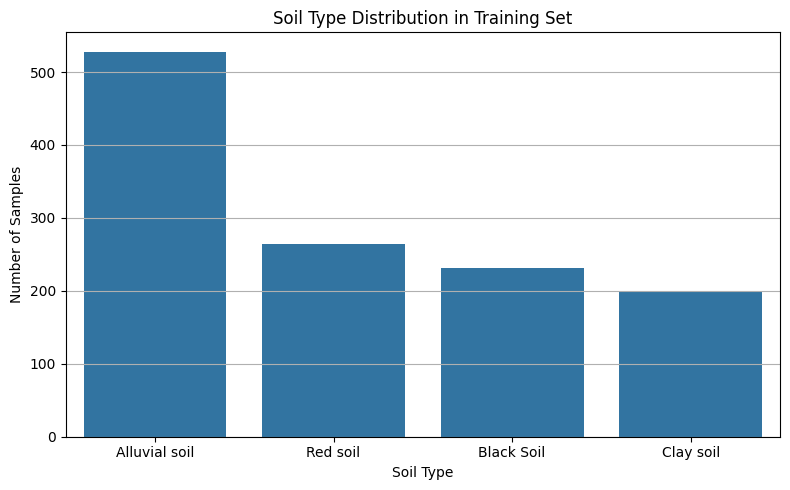

🌱 Detected Soil Classes: ['Alluvial soil', 'Black Soil', 'Clay soil', 'Red soil']


In [ ]:
# Import necessary libraries for data handling and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load the training labels CSV
train_df = pd.read_csv(train_csv_path)
print("✅ Loaded training labels. Shape:", train_df.shape)
display(train_df.head())

# Data integrity checks
print("\n🔍 Checking for missing values and duplicates in training data...")
print("Missing values per column:\n", train_df.isnull().sum())
print("Number of duplicate rows:", train_df.duplicated().sum())

# Verify all referenced training images exist in the directory
missing_images = [
    img for img in train_df['image_id']
    if not os.path.exists(os.path.join(train_img_dir, img))
]
print(f"🚨 Missing training images: {len(missing_images)}")
assert len(missing_images) == 0, "Some training images are missing!"

# Visualize class distribution for soil types
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='soil_type', order=train_df['soil_type'].value_counts().index)
plt.title("Soil Type Distribution in Training Set")
plt.xlabel("Soil Type")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Save list of soil classes for later use
soil_classes = sorted(train_df['soil_type'].unique())
print("🌱 Detected Soil Classes:", soil_classes)

Set Seed, Imports for Training, and Define Utility Functions


In [ ]:
# ======= Setup for Training =======
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
import timm
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import time

# Seed everything for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


Encode Labels & Dataset Class with Transformations


In [ ]:
# ======= Encode Labels =======
soil_to_idx = {soil: idx for idx, soil in enumerate(soil_classes)}
idx_to_soil = {idx: soil for soil, idx in soil_to_idx.items()}
print(f"Class to index mapping: {soil_to_idx}")

train_df['label'] = train_df['soil_type'].map(soil_to_idx)

# ======= Dataset Class =======
class SoilDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id']
        label = self.df.loc[idx, 'label']
        path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(path).convert("RGB")
        except (FileNotFoundError, UnidentifiedImageError):
            print(f"⚠️ Skipping image: {img_name}")
            image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

# ======= Data Augmentation and Normalization =======
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


Class to index mapping: {'Alluvial soil': 0, 'Black Soil': 1, 'Clay soil': 2, 'Red soil': 3}


Define MixUp Function for Data Augmentation


In [ ]:
# ======= MixUp Augmentation =======
def mixup_data(x, y, alpha=0.4):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


Prepare Class Weights, Model, Loss, Optimizer, Scheduler

In [ ]:
# ======= Class Weights for Imbalanced Data =======
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum()
print(f"Class Weights: {class_weights}")

# ======= Model =======
def get_model():
    model = timm.create_model('seresnext50_32x4d', pretrained=True, num_classes=len(soil_classes))
    return model.to(device)

# ======= Loss, Optimizer, Scheduler =======
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
learning_rate = 1e-4
weight_decay = 1e-4
num_epochs = 15

Class Weights: tensor([0.1260, 0.2879, 0.3342, 0.2519])


Define Training and Validation Loops with MixUp and Per-class F1 Logging


In [ ]:
# ======= Training Loop =======
def train_one_epoch(model, loader, optimizer, criterion, mixup_alpha=0.4):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        if mixup_alpha > 0:
            images, targets_a, targets_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()

        if mixup_alpha > 0:
            # For mixup, hard to get exact preds so just use preds from outputs
            all_preds.extend(preds)
            all_targets.extend(labels.detach().cpu().numpy())  # original labels
        else:
            all_preds.extend(preds)
            all_targets.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_targets, all_preds, average='macro')
    return avg_loss, f1_macro

# ======= Validation Loop =======
from sklearn.metrics import precision_score, recall_score

def validate_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_targets, all_preds, average='macro')
    f1_per_class = f1_score(all_targets, all_preds, average=None)
    min_f1 = f1_per_class.min()

    # Add precision and recall (macro averaged)
    precision_macro = precision_score(all_targets, all_preds, average='macro')
    recall_macro = recall_score(all_targets, all_preds, average='macro')

    return avg_loss, f1_macro, f1_per_class, min_f1, precision_macro, recall_macro

Prepare Stratified K-Fold and Training Loop (with model saving and fold reporting)

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
import time

# Hyperparameters
n_splits = 3
num_epochs = 20  # Set higher, early stopping will cut off if needed
early_stopping_patience = 3
min_delta = 0.001
batch_size = 32
learning_rate = 1e-4
weight_decay = 1e-4

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Store models per fold
fold_models = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
    print(f"\n========== Fold {fold + 1}/{n_splits} ==========")

    # Prepare datasets for this fold
    train_subset = train_df.iloc[train_idx].reset_index(drop=True)
    val_subset = train_df.iloc[val_idx].reset_index(drop=True)

    train_dataset = SoilDataset(train_subset, train_img_dir, transform=train_transforms)
    val_dataset = SoilDataset(val_subset, train_img_dir, transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Initialize model, optimizer, scheduler
    model = get_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

    best_val_f1 = 0
    best_model_path = f"best_model_fold{fold}.pth"
    no_improvement_counter = 0

    for epoch in range(num_epochs):
        start_time = time.time()

        # Training
        train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, mixup_alpha=0.4)
        # Validation
        val_loss, val_f1, val_f1_per_class, val_min_f1, val_precision, val_recall = validate_one_epoch(model, val_loader, criterion)

        scheduler.step(val_f1)

        elapsed = time.time() - start_time

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Macro F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Macro F1: {val_f1:.4f}, "
              f"Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, "
              f"Min Class F1: {val_min_f1:.4f} | Time: {elapsed:.1f}s")

        # Early Stopping
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            no_improvement_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            no_improvement_counter += 1
            print(f"No improvement for {no_improvement_counter}/{early_stopping_patience} epochs")
            if no_improvement_counter >= early_stopping_patience:
                print(f"Early stopping at epoch {epoch+1} (best Val F1: {best_val_f1:.4f})")
                break

    print(f"Best Val Macro F1 for Fold {fold+1}: {best_val_f1:.4f}")

    # Load best model for inference later
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    fold_models.append(model)



========== Fold 1/3 ==========


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/20] - Train Loss: 1.2574, Train Macro F1: 0.3815 | Val Loss: 1.0674, Val Macro F1: 0.7821, Precision: 0.7976, Recall: 0.8109, Min Class F1: 0.6771 | Time: 23.8s
Epoch [2/20] - Train Loss: 0.9179, Train Macro F1: 0.6170 | Val Loss: 0.6844, Val Macro F1: 0.8663, Precision: 0.8592, Recall: 0.9048, Min Class F1: 0.7929 | Time: 25.5s
Epoch [3/20] - Train Loss: 0.7195, Train Macro F1: 0.6008 | Val Loss: 0.5333, Val Macro F1: 0.8598, Precision: 0.8512, Recall: 0.8993, Min Class F1: 0.8049 | Time: 24.3s
No improvement for 1/3 epochs
Epoch [4/20] - Train Loss: 0.5488, Train Macro F1: 0.5356 | Val Loss: 0.4194, Val Macro F1: 0.8991, Precision: 0.8907, Recall: 0.9242, Min Class F1: 0.8742 | Time: 23.6s
Epoch [5/20] - Train Loss: 0.6194, Train Macro F1: 0.6264 | Val Loss: 0.4179, Val Macro F1: 0.8807, Precision: 0.8756, Recall: 0.9121, Min Class F1: 0.8098 | Time: 26.8s
No improvement for 1/3 epochs
Epoch [6/20] - Train Loss: 0.4258, Train Macro F1: 0.6033 | Val Loss: 0.3485, Val Macro F1

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/20] - Train Loss: 1.2652, Train Macro F1: 0.4349 | Val Loss: 1.0249, Val Macro F1: 0.7810, Precision: 0.7888, Recall: 0.8078, Min Class F1: 0.6961 | Time: 23.0s
Epoch [2/20] - Train Loss: 0.9520, Train Macro F1: 0.4800 | Val Loss: 0.5931, Val Macro F1: 0.8868, Precision: 0.8689, Recall: 0.9206, Min Class F1: 0.8533 | Time: 25.5s
Epoch [3/20] - Train Loss: 0.7102, Train Macro F1: 0.5562 | Val Loss: 0.3926, Val Macro F1: 0.9304, Precision: 0.9179, Recall: 0.9541, Min Class F1: 0.8627 | Time: 23.9s
Epoch [4/20] - Train Loss: 0.5888, Train Macro F1: 0.6763 | Val Loss: 0.3419, Val Macro F1: 0.9189, Precision: 0.9057, Recall: 0.9489, Min Class F1: 0.8354 | Time: 24.7s
No improvement for 1/3 epochs
Epoch [5/20] - Train Loss: 0.5374, Train Macro F1: 0.5476 | Val Loss: 0.2950, Val Macro F1: 0.9191, Precision: 0.9053, Recall: 0.9403, Min Class F1: 0.8630 | Time: 22.7s
No improvement for 2/3 epochs
Epoch [6/20] - Train Loss: 0.5755, Train Macro F1: 0.6838 | Val Loss: 0.3056, Val Macro F1

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/20] - Train Loss: 1.2853, Train Macro F1: 0.3399 | Val Loss: 1.0093, Val Macro F1: 0.8135, Precision: 0.8082, Recall: 0.8367, Min Class F1: 0.7516 | Time: 24.6s
Epoch [2/20] - Train Loss: 0.9114, Train Macro F1: 0.5369 | Val Loss: 0.5642, Val Macro F1: 0.8999, Precision: 0.8921, Recall: 0.9149, Min Class F1: 0.8533 | Time: 24.3s
Epoch [3/20] - Train Loss: 0.6597, Train Macro F1: 0.5663 | Val Loss: 0.3467, Val Macro F1: 0.9184, Precision: 0.9141, Recall: 0.9324, Min Class F1: 0.8627 | Time: 23.9s
Epoch [4/20] - Train Loss: 0.6689, Train Macro F1: 0.5326 | Val Loss: 0.2896, Val Macro F1: 0.9496, Precision: 0.9412, Recall: 0.9619, Min Class F1: 0.9231 | Time: 24.5s
Epoch [5/20] - Train Loss: 0.6294, Train Macro F1: 0.5726 | Val Loss: 0.2750, Val Macro F1: 0.9583, Precision: 0.9500, Recall: 0.9690, Min Class F1: 0.9362 | Time: 24.7s
Epoch [6/20] - Train Loss: 0.5298, Train Macro F1: 0.7265 | Val Loss: 0.2320, Val Macro F1: 0.9605, Precision: 0.9543, Recall: 0.9675, Min Class F1: 0

Define Enhanced Test Time Augmentation (TTA) and Prediction Function (Ensembling Fold Models)

In [ ]:
# ======= Enhanced Test Time Augmentation (TTA) =======
tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
]

# A deterministic way to apply TTA (manual flips instead of random)
def apply_tta(image):
    images = []
    # Original
    images.append(transforms.functional.resize(image, (224, 224)))
    # Horizontal flip
    images.append(transforms.functional.hflip(images[0]))
    # Vertical flip
    images.append(transforms.functional.vflip(images[0]))
    return images

def predict_with_tta(models, dataset):
    all_preds = []

    for idx in range(len(dataset)):
        img_pil = Image.open(os.path.join(test_img_dir, dataset.df.loc[idx, 'image_id'])).convert("RGB")
        tta_images = apply_tta(img_pil)
        tta_preds = []

        for img in tta_images:
            img_t = val_transforms(img).unsqueeze(0).to(device)

            fold_preds = []
            for model in models:
                model.eval()
                with torch.no_grad():
                    output = model(img_t)
                    fold_preds.append(torch.softmax(output, dim=1).cpu().numpy())

            # Average over folds
            avg_pred = np.mean(fold_preds, axis=0)
            tta_preds.append(avg_pred)

        # Average over TTA
        final_pred = np.mean(tta_preds, axis=0)
        predicted_class = final_pred.argmax()
        all_preds.append(predicted_class)

    return all_preds


Prepare Test Dataset and Predict on Test Set, Save Submission CSV

In [ ]:
# ======= Prepare Test Dataset =======
test_df = pd.read_csv(test_csv_path)
print(f"Test dataset loaded: {test_df.shape}")

class TestDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id']
        path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(path).convert("RGB")
        except (FileNotFoundError, UnidentifiedImageError):
            print(f"⚠️ Skipping test image: {img_name}")
            image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, img_name

test_dataset = TestDataset(test_df, test_img_dir, transform=val_transforms)

# ======= Predict on Test Set =======
print("\nStarting Test Set Predictions with Ensemble and TTA...")
test_preds = predict_with_tta(fold_models, test_dataset)

# Map predicted class indices back to soil types
test_preds_labels = [idx_to_soil[p] for p in test_preds]

submission = pd.DataFrame({
    'image_id': test_df['image_id'],
    'soil_type': test_preds_labels
})

# Save directly into Google Drive folder
submission_file = '/content/drive/MyDrive/ANNAM.AI Hackathon/submission_3Fold.csv'
submission.to_csv(submission_file, index=False)
print(f"Submission file saved: {submission_file}")


Test dataset loaded: (341, 1)

Starting Test Set Predictions with Ensemble and TTA...
Submission file saved: /content/drive/MyDrive/ANNAM.AI Hackathon/submission_3Fold.csv


Sample predictions: ['Alluvial soil', 'Alluvial soil', 'Alluvial soil', 'Alluvial soil', 'Alluvial soil']
Sample actuals:     ['Alluvial soil', 'Alluvial soil', 'Alluvial soil', 'Alluvial soil', 'Alluvial soil']


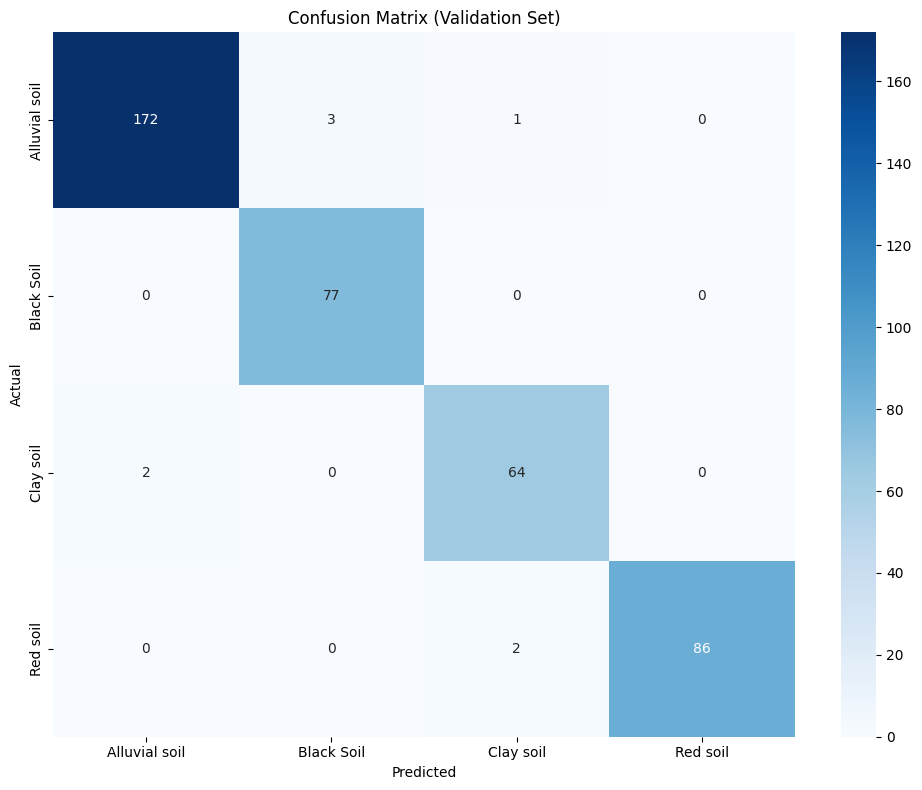


Classification Report:
               precision    recall  f1-score   support

Alluvial soil     0.9885    0.9773    0.9829       176
   Black Soil     0.9625    1.0000    0.9809        77
    Clay soil     0.9552    0.9697    0.9624        66
     Red soil     1.0000    0.9773    0.9885        88

     accuracy                         0.9803       407
    macro avg     0.9766    0.9811    0.9787       407
 weighted avg     0.9807    0.9803    0.9804       407


Macro F1 Score:      0.9787
Precision (macro):   0.9766
Recall (macro):      0.9811
Minimum Class F1:    0.9624


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

def evaluate_and_plot_confusion_matrix(model, val_loader, soil_classes):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            targets = labels.cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(targets)

    # Convert indices to class names
    y_true = [idx_to_soil[idx] for idx in all_targets]
    y_pred = [idx_to_soil[idx] for idx in all_preds]

    # Debug print first 5 predictions to ensure output
    print("Sample predictions:", y_pred[:5])
    print("Sample actuals:    ", y_true[:5])

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred, labels=soil_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=soil_classes, yticklabels=soil_classes, cmap="Blues")
    plt.title("Confusion Matrix (Validation Set)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # ===== Classification Report =====
    print("\nClassification Report:")
    report_text = classification_report(y_true, y_pred, labels=soil_classes, digits=4)
    print(report_text)

    # ===== Macro Metrics =====
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    per_class_f1 = f1_score(y_true, y_pred, average=None, labels=soil_classes)
    min_f1 = per_class_f1.min()

    print(f"\nMacro F1 Score:      {macro_f1:.4f}")
    print(f"Precision (macro):   {precision:.4f}")
    print(f"Recall (macro):      {recall:.4f}")
    print(f"Minimum Class F1:    {min_f1:.4f}")

# Prepare validation dataset and dataloader for evaluation (example: last fold validation set)
val_dataset = SoilDataset(val_subset, train_img_dir, transform=val_transforms)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Evaluate and plot confusion matrix for the last fold model
evaluate_and_plot_confusion_matrix(fold_models[-1], val_loader, soil_classes=soil_classes)
